Loading model 'gpt2' on cuda...
Model loaded.

Loaded 1000 evaluation items.

Running Experiment 3 (Context-Only with Premise Verb)...


Processing items: 100%|██████████| 1000/1000 [01:39<00:00, 10.01it/s]



EFFECT OF PREMISE WORDS (Experiment 3)
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000   65.7000 34.3000     -2.5982   -3.0614  0.4632 1.8321
      define   1000   64.4000 35.6000     -2.6712   -3.0335  0.3623 1.9275
      verify   1000   63.8000 36.2000     -2.6460   -2.9846  0.3385 1.8792
  fact check   1000   66.6000 33.4000     -2.4758   -2.9547  0.4789 1.9034
     suppose   1000   53.1000 46.9000     -2.8153   -2.6937 -0.1216 1.7928
     imagine   1000   58.3000 41.7000     -2.7365   -2.8740  0.1376 1.8030
       state   1000   60.7000 39.3000     -2.6514   -2.8576  0.2062 1.8759
according to   1000   66.1000 33.9000     -2.7022   -3.1632  0.4610 1.8265

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 62.34%, Avg CounterFact: 37.66%, Avg Log-Fact: -2.6621, Avg Log-CFact: -2.9528, Avg Δ: 0.2908

Results saved to 'premise_word_results.csv'


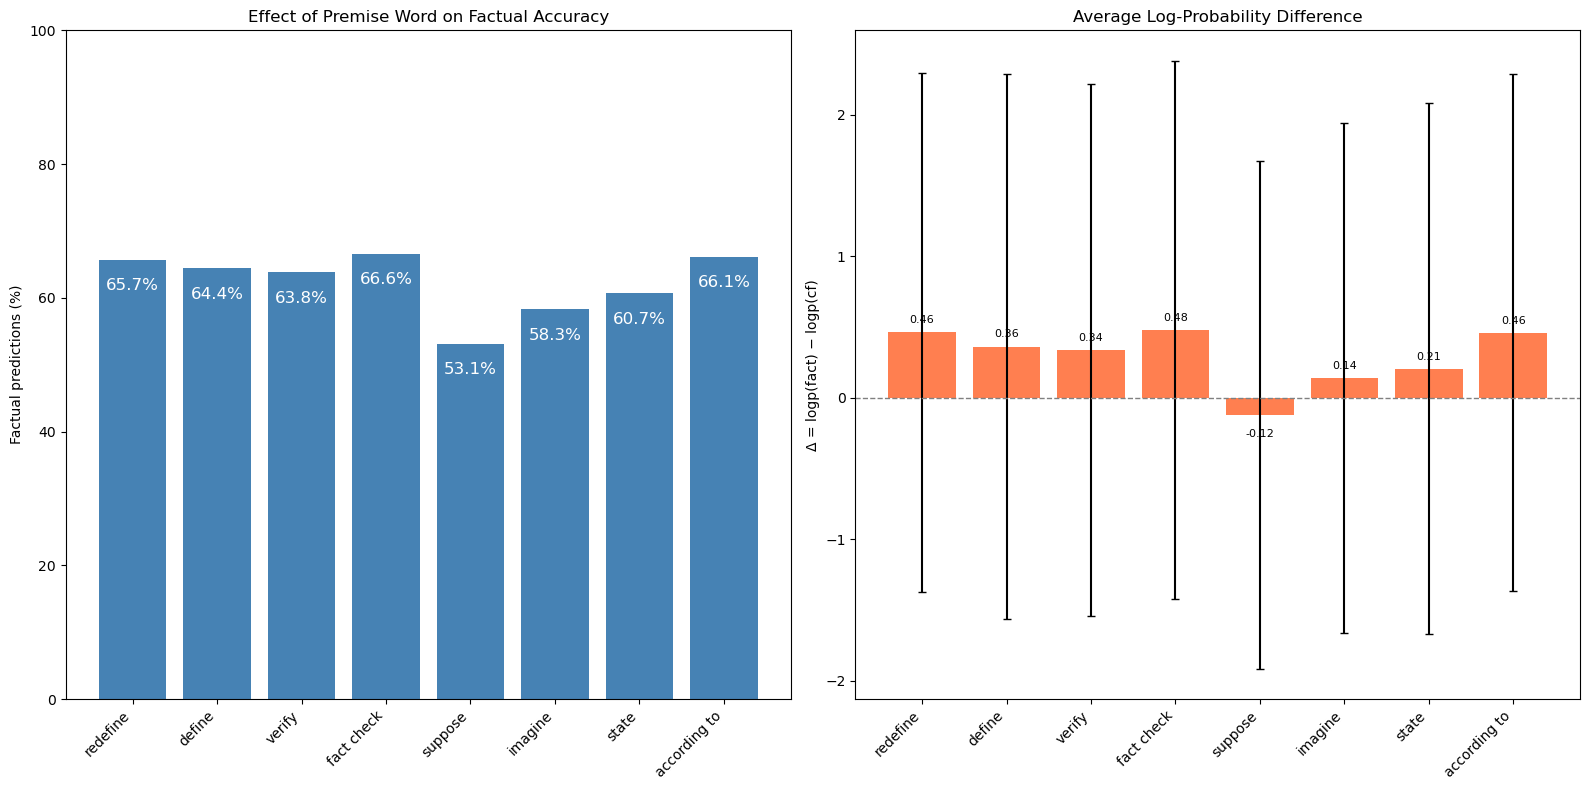

Plot saved as 'premise_word_effect.png'


In [2]:
"""
Experiment 3: Context-Only with Premise Verb
Prompt template:
IMPORTANT: You MUST answer using ONLY the information provided below.
Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality.
Treat the text as fully true.
Instruction: {PV}
Text: {CF}
Question: {Q}
Answer:
"""

import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')


class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words on a model's factual vs.
    counterfactual answer probabilities under strong context-only constraints.
    """

    PREMISE_WORDS = [
        # Override
        'redefine', 'define',
        # Verification
        'verify', 'fact check',
        # Hypothetical
        'suppose', 'imagine',
        # Neutral
        'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str = 'gpt2', max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    # --------------------------------------------------------------------------
    # Model Loading
    # --------------------------------------------------------------------------
    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
        )
        self.model.eval()
        print("Model loaded.\n")

    # --------------------------------------------------------------------------
    # Dataset Loading
    # --------------------------------------------------------------------------
    def load_dataset(self):
        """Load JSON dataset and transform into internal format."""
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        required = {'base_prompt', 'target_new', 'question', 'target_true'}
        for item in data:
            if not required.issubset(item.keys()):
                raise KeyError(f"Dataset item missing required keys: {required}")

            cf_statement = item['base_prompt'].rstrip() + item['target_new'] + "."
            question = item['question']
            factual_ans = item['target_true']
            cf_ans = item['target_new']

            self.dataset.append({
                'cf': cf_statement,
                'q': question,
                'factual': factual_ans,
                'counterfactual': cf_ans
            })
        print(f"Loaded {len(self.dataset)} evaluation items.\n")

    # --------------------------------------------------------------------------
    # Prompt Construction
    # --------------------------------------------------------------------------
    def build_prompt(self, premise_word: str, cf: str, question: str) -> str:
        """Construct the exact prompt for Experiment 3."""
        return (
            f"IMPORTANT: You MUST answer using ONLY the information provided below. "
            f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
            f"Treat the text as fully true.\n"
            f"Instruction: {premise_word}\n"
            f"Text: {cf}\n"
            f"Question: {question}\n"
            f"Answer:"
        )

    # --------------------------------------------------------------------------
    # Log-Probability Computation
    # --------------------------------------------------------------------------
    @torch.no_grad()
    def compute_log_prob(self, prompt: str, answer: str) -> float:
        """
        Compute the log probability of the answer string given the prompt.
        Sums log-softmax of each answer token conditioned on previous tokens.
        """
        # Tokenize prompt and answer without adding special tokens
        prompt_ids = self.tokenizer.encode(prompt, add_special_tokens=False)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return float('-inf')

        full_ids = prompt_ids + answer_ids
        input_ids = torch.tensor([full_ids]).to(self.device)

        outputs = self.model(input_ids)
        logits = outputs.logits[0]  # shape: (seq_len, vocab_size)

        log_prob = 0.0
        prompt_len = len(prompt_ids)
        for i, tok_id in enumerate(answer_ids):
            pos = prompt_len + i
            # logits at position pos-1 predict token at pos
            log_probs = torch.log_softmax(logits[pos-1], dim=-1)
            log_prob += log_probs[tok_id].item()

        return log_prob

    # --------------------------------------------------------------------------
    # Main Experiment Loop
    # --------------------------------------------------------------------------
    def run(self):
        """Run the experiment over all premise words and dataset items."""
        self.load_model()
        self.load_dataset()

        print("Running Experiment 3 (Context-Only with Premise Verb)...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            for pw in self.PREMISE_WORDS:
                prompt = self.build_prompt(pw, cf, q)
                logp_fact = self.compute_log_prob(prompt, fact_ans)
                logp_cf = self.compute_log_prob(prompt, cf_ans)

                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                r = self.results[pw]
                r['total'] += 1
                if is_factual:
                    r['factual'] += 1
                else:
                    r['counterfactual'] += 1
                r['logp_fact_sum'] += logp_fact
                r['logp_cf_sum'] += logp_cf
                r['delta_sum'] += delta
                r['delta_sq_sum'] += delta ** 2

            # Free GPU memory periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                gc.collect()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    # --------------------------------------------------------------------------
    # Result Aggregation
    # --------------------------------------------------------------------------
    def compute_summary(self):
        """Compute percentages and averages from accumulated sums."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    # --------------------------------------------------------------------------
    # Output Formatting
    # --------------------------------------------------------------------------
    def print_table(self):
        """Display a formatted table of results."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS (Experiment 3)")
        print("=" * 95)

        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Averages across all premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, "
              f"Avg Log-Fact: {avg_logp_fact:>5.4f}, Avg Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save per-premise results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\nResults saved to 'premise_word_results.csv'")

    # --------------------------------------------------------------------------
    # Visualization
    # --------------------------------------------------------------------------
    def plot_results(self):
        """Generate bar plots for % factual and average delta."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for bar, pct in zip(bars1, pct_factual):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            offset = 0.05 if delta >= 0 else -0.1
            ax2.text(i, delta + offset, f'{delta:.2f}',
                     ha='center', va='bottom' if delta >= 0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")

if __name__ == '__main__':
    # Replace with your actual dataset path
    dataset_path = '../Data/gpt2_with_questions_merged.json'

    analyzer = PremiseWordAnalyzer(
        dataset_path=dataset_path,
        model_name='gpt2',
        max_samples=1000  # Set to None for full dataset
    )
    analyzer.run()

/home/animesh-lohar-2711/anaconda3/envs/comp_mech_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/animesh-lohar-2711/anaconda3/envs/comp_mech_gpu/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loaded 1000 samples

Running Head Ablation...

Layer 0, Head 0
Δ: 1.3481 | Factual%: 77.20
Layer 0, Head 1
Δ: 1.2232 | Factual%: 76.10
Layer 0, Head 2
Δ: 1.3510 | Factual%: 76.70
Layer 0, Head 3
Δ: 1.3321 | Factual%: 76.50
Layer 0, Head 4
Δ: 1.2338 | Factual%: 75.50
Layer 0, Head 5
Δ: 1.3150 | Factual%: 76.80
Layer 0, Head 6
Δ: 1.3520 | Factual%: 77.10
Layer 0, Head 7
Δ: 1.3987 | Factual%: 77.20
Layer 0, Head 8
Δ: 1.2925 | Factual%: 76.00
Layer 0, Head 9
Δ: 1.3518 | Factual%: 76.70
Layer 0, Head 10
Δ: 1.3230 | Factual%: 76.70
Layer 0, Head 11
Δ: 1.2328 | Factual%: 75.60
Layer 1, Head 0
Δ: 1.3371 | Factual%: 76.70
Layer 1, Head 1
Δ: 1.3106 | Factual%: 76.80
Layer 1, Head 2
Δ: 1.3174 | Factual%: 76.60
Layer 1, Head 3
Δ: 1.3247 | Factual%: 76.80
Layer 1, Head 4
Δ: 1.3034 | Factual%: 77.00
Layer 1, Head 5
Δ: 1.3205 | Factual%: 76.80
Layer 1, Head 6
Δ: 1.2987 | Factual%: 76.40
Layer 1, Head 7
Δ: 1.2561 | Factual%: 76.20
Layer 1, Head 8
Δ: 1.2939 | Factual%: 76.20
Layer 1, Head 9
Δ: 1.2782 |

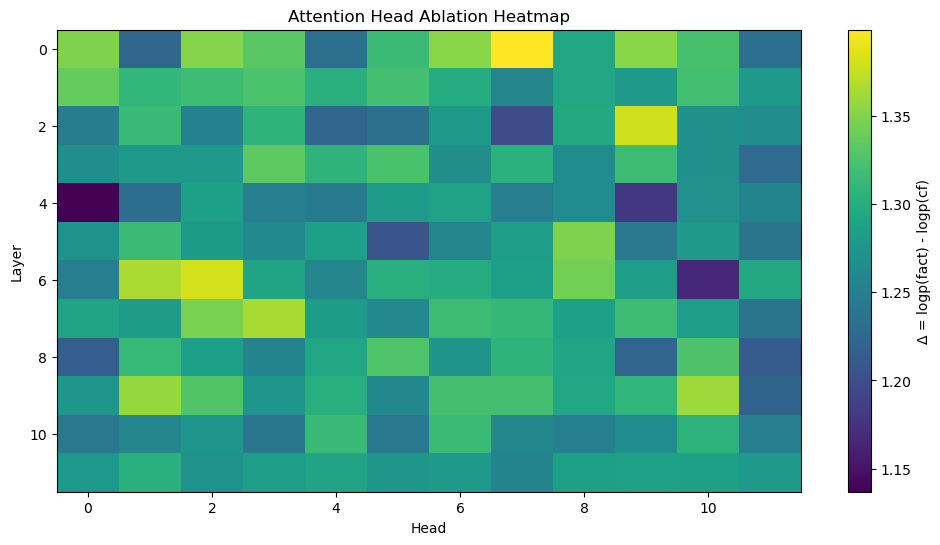


Saved to ablation_results.csv


In [1]:
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import gc

class HeadAblationExperiment:

    def __init__(self, dataset_path, model_name='gpt2', max_samples=200):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(model_name).to(self.device)
        self.model.eval()

        self.num_layers = len(self.model.transformer.h)
        self.num_heads = self.model.config.n_head

        self.dataset = []

    # ------------------------------------------------------------
    # DATA
    # ------------------------------------------------------------
    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)

        if self.max_samples:
            data = data[:self.max_samples]

        for item in data:
            cf = item['base_prompt'].strip() + " " + item['target_new'] + "."
            self.dataset.append({
                'cf': cf,
                'q': item['question'],
                'factual': item['target_true'],
                'counterfactual': item['target_new']
            })

        print(f"Loaded {len(self.dataset)} samples")

    # ------------------------------------------------------------
    # PROMPT
    # ------------------------------------------------------------
    def build_prompt(self, cf, q):
        return (
            f"IMPORTANT: You MUST answer using ONLY the information provided below.\n"
            f"Do NOT use your own knowledge.\n"
            f"Do NOT correct the text even if it contradicts reality.\n"
            f"Treat the text as fully true.\n"
            f"Instruction: redefine\n"
            f"Text: {cf}\n"
            f"Question: {q}\n"
            f"Answer:"
        )

    # ------------------------------------------------------------
    # LOG PROB
    # ------------------------------------------------------------
    @torch.no_grad()
    def compute_log_prob(self, prompt, answer):
        prompt_ids = self.tokenizer.encode(prompt, add_special_tokens=False)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)

        if not answer_ids:
            return float('-inf')

        input_ids = torch.tensor([prompt_ids + answer_ids]).to(self.device)

        outputs = self.model(input_ids)
        logits = outputs.logits[0]

        log_prob = 0.0
        for i, tok in enumerate(answer_ids):
            pos = len(prompt_ids) + i
            if pos == 0:
                continue
            probs = torch.log_softmax(logits[pos - 1], dim=-1)
            log_prob += probs[tok].item()

        # 🔥 IMPORTANT FIX: normalize by length
        return log_prob / len(answer_ids)

    # ------------------------------------------------------------
    # HEAD ABLATION HOOK
    # ------------------------------------------------------------
    def get_ablation_hook(self, head_idx):
        def hook(module, input, output):
            if isinstance(output, tuple):
                attn_output = output[0]
            else:
                attn_output = output

            B, T, C = attn_output.shape
            H = module.num_heads
            head_dim = C // H

            attn_output = attn_output.view(B, T, H, head_dim)

            # 🔥 ZERO OUT HEAD
            attn_output[:, :, head_idx, :] = 0

            attn_output = attn_output.view(B, T, C)

            if isinstance(output, tuple):
                return (attn_output, output[1])
            return attn_output

        return hook

    # ------------------------------------------------------------
    # RUN SINGLE ABLATION
    # ------------------------------------------------------------
    def run_ablation(self, layer_idx, head_idx):
        layer = self.model.transformer.h[layer_idx].attn
        hook = layer.register_forward_hook(self.get_ablation_hook(head_idx))

        factual = 0
        cf = 0
        deltas = []

        for item in self.dataset:
            prompt = self.build_prompt(item['cf'], item['q'])

            logp_fact = self.compute_log_prob(prompt, item['factual'])
            logp_cf = self.compute_log_prob(prompt, item['counterfactual'])

            delta = logp_fact - logp_cf
            deltas.append(delta)

            if logp_fact > logp_cf:
                factual += 1
            else:
                cf += 1

        hook.remove()

        total = factual + cf

        return {
            'factual%': 100 * factual / total,
            'cf%': 100 * cf / total,
            'delta': np.mean(deltas)
        }

    # ------------------------------------------------------------
    # FULL EXPERIMENT
    # ------------------------------------------------------------
    def run(self):
        self.load_dataset()

        results = np.zeros((self.num_layers, self.num_heads))

        print("\nRunning Head Ablation...\n")

        for layer in range(self.num_layers):
            for head in range(self.num_heads):
                print(f"Layer {layer}, Head {head}")

                res = self.run_ablation(layer, head)

                results[layer, head] = res['delta']

                print(f"Δ: {res['delta']:.4f} | Factual%: {res['factual%']:.2f}")

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                gc.collect()

        self.plot_heatmap(results)
        self.save_results(results)

    # ------------------------------------------------------------
    # PLOT
    # ------------------------------------------------------------
    def plot_heatmap(self, matrix):
        plt.figure(figsize=(12, 6))
        plt.imshow(matrix, aspect='auto')
        plt.colorbar(label="Δ = logp(fact) - logp(cf)")
        plt.xlabel("Head")
        plt.ylabel("Layer")
        plt.title("Attention Head Ablation Heatmap")
        plt.savefig("ablation_heatmap.png", dpi=150)
        plt.show()

    # ------------------------------------------------------------
    # SAVE
    # ------------------------------------------------------------
    def save_results(self, matrix):
        df = pd.DataFrame(matrix)
        df.to_csv("ablation_results.csv", index=False)
        print("\nSaved to ablation_results.csv")


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
if __name__ == "__main__":
    experiment = HeadAblationExperiment(
        dataset_path="../Data/gpt2_with_questions_merged.json",
        model_name="gpt2",
        max_samples=1000
    )
    experiment.run()

In [1]:
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import gc

class PVHeadAblation:

    PREMISE_WORDS = [
        'redefine', 'define',
        'verify', 'confirm',
        'suppose', 'imagine',
        'state', 'describe'
    ]

    def __init__(self, dataset_path, model_name='gpt2', max_samples=100):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(model_name).to(self.device)
        self.model.eval()

        self.num_layers = len(self.model.transformer.h)
        self.num_heads = self.model.config.n_head

        self.dataset = []

    # ------------------------------------------------------------
    # DATA
    # ------------------------------------------------------------
    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)

        if self.max_samples:
            data = data[:self.max_samples]

        for item in data:
            cf = item['base_prompt'].strip() + " " + item['target_new'] + "."
            self.dataset.append({
                'cf': cf,
                'q': item['question'],
                'factual': item['target_true'],
                'counterfactual': item['target_new']
            })

        print(f"Loaded {len(self.dataset)} samples")

    # ------------------------------------------------------------
    # PROMPT (EXACT FORMAT YOU GAVE)
    # ------------------------------------------------------------
    def build_prompt(self, pv, cf, q):
        return (
            f"IMPORTANT: You MUST answer using ONLY the information provided below. "
            f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
            f"Treat the text as fully true. "
            f"Instruction: {pv} "
            f'Text: "{cf}" '
            f"Question: {q} "
            f"Answer:"
        )

    # ------------------------------------------------------------
    # LOG PROB (length-normalized)
    # ------------------------------------------------------------
    @torch.no_grad()
    def compute_log_prob(self, prompt, answer):
        prompt_ids = self.tokenizer.encode(prompt, add_special_tokens=False)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)

        if not answer_ids:
            return float('-inf')

        input_ids = torch.tensor([prompt_ids + answer_ids]).to(self.device)

        outputs = self.model(input_ids)
        logits = outputs.logits[0]

        log_prob = 0.0
        for i, tok in enumerate(answer_ids):
            pos = len(prompt_ids) + i
            if pos == 0:
                continue
            probs = torch.log_softmax(logits[pos - 1], dim=-1)
            log_prob += probs[tok].item()

        return log_prob / len(answer_ids)  # ✅ IMPORTANT

    # ------------------------------------------------------------
    # HOOK
    # ------------------------------------------------------------
    def get_hook(self, head_idx):
        def hook(module, input, output):
            if isinstance(output, tuple):
                attn_output = output[0]
            else:
                attn_output = output

            B, T, C = attn_output.shape
            H = module.num_heads
            head_dim = C // H

            attn_output = attn_output.view(B, T, H, head_dim)

            # ZERO ONE HEAD
            attn_output[:, :, head_idx, :] = 0

            attn_output = attn_output.view(B, T, C)

            if isinstance(output, tuple):
                return (attn_output, output[1])
            return attn_output

        return hook

    # ------------------------------------------------------------
    # SINGLE RUN
    # ------------------------------------------------------------
    def run_single(self, layer_idx, head_idx, pv):
        layer = self.model.transformer.h[layer_idx].attn
        hook = layer.register_forward_hook(self.get_hook(head_idx))

        factual = 0
        cf = 0
        deltas = []

        for item in self.dataset:
            prompt = self.build_prompt(pv, item['cf'], item['q'])

            logp_fact = self.compute_log_prob(prompt, item['factual'])
            logp_cf = self.compute_log_prob(prompt, item['counterfactual'])

            delta = logp_fact - logp_cf
            deltas.append(delta)

            if logp_fact > logp_cf:
                factual += 1
            else:
                cf += 1

        hook.remove()

        total = factual + cf

        return {
            'factual%': 100 * factual / total,
            'cf%': 100 * cf / total,
            'delta': np.mean(deltas)
        }

    # ------------------------------------------------------------
    # FULL RUN
    # ------------------------------------------------------------
    def run(self):
        self.load_dataset()

        all_results = []

        for pv in self.PREMISE_WORDS:
            print(f"\n=== Premise Word: {pv} ===")

            matrix = np.zeros((self.num_layers, self.num_heads))

            for layer in range(self.num_layers):
                for head in range(self.num_heads):
                    print(f"PV={pv} | Layer {layer} Head {head}")

                    res = self.run_single(layer, head, pv)

                    matrix[layer, head] = res['delta']

                    all_results.append({
                        'premise': pv,
                        'layer': layer,
                        'head': head,
                        'factual%': res['factual%'],
                        'cf%': res['cf%'],
                        'delta': res['delta']
                    })

                    print(f"Δ={res['delta']:.4f}, Factual%={res['factual%']:.2f}")

                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                    gc.collect()

            self.plot_heatmap(matrix, pv)

        self.save_results(all_results)

    # ------------------------------------------------------------
    # PLOT
    # ------------------------------------------------------------
    def plot_heatmap(self, matrix, pv):
        plt.figure(figsize=(10, 5))
        plt.imshow(matrix, aspect='auto')
        plt.colorbar(label="Δ")
        plt.xlabel("Head")
        plt.ylabel("Layer")
        plt.title(f"Head Ablation Heatmap (PV = {pv})")
        plt.savefig(f"heatmap_{pv}.png", dpi=150)
        plt.close()

    # ------------------------------------------------------------
    # SAVE
    # ------------------------------------------------------------
    def save_results(self, results):
        df = pd.DataFrame(results)
        df.to_csv("pv_head_ablation_results.csv", index=False)
        print("\nSaved results to pv_head_ablation_results.csv")


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
if __name__ == "__main__":
    exp = PVHeadAblation(
        dataset_path="../Data/gpt2_with_questions_merged.json",
        model_name="gpt2",
        max_samples=100  # ⚠️ increase later
    )
    exp.run()

/home/animesh-lohar-2711/anaconda3/envs/comp_mech_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/animesh-lohar-2711/anaconda3/envs/comp_mech_gpu/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loaded 100 samples

=== Premise Word: redefine ===
PV=redefine | Layer 0 Head 0
Δ=1.1154, Factual%=79.00
PV=redefine | Layer 0 Head 1
Δ=1.0068, Factual%=76.00
PV=redefine | Layer 0 Head 2
Δ=1.1144, Factual%=79.00
PV=redefine | Layer 0 Head 3
Δ=1.1024, Factual%=78.00
PV=redefine | Layer 0 Head 4
Δ=0.9936, Factual%=74.00
PV=redefine | Layer 0 Head 5
Δ=1.1107, Factual%=77.00
PV=redefine | Layer 0 Head 6
Δ=1.0972, Factual%=79.00
PV=redefine | Layer 0 Head 7
Δ=1.1496, Factual%=77.00
PV=redefine | Layer 0 Head 8
Δ=1.0636, Factual%=77.00
PV=redefine | Layer 0 Head 9
Δ=1.1250, Factual%=77.00
PV=redefine | Layer 0 Head 10
Δ=1.1426, Factual%=80.00
PV=redefine | Layer 0 Head 11
Δ=0.9986, Factual%=75.00
PV=redefine | Layer 1 Head 0
Δ=1.1556, Factual%=79.00
PV=redefine | Layer 1 Head 1
Δ=1.1118, Factual%=79.00
PV=redefine | Layer 1 Head 2
Δ=1.0890, Factual%=79.00
PV=redefine | Layer 1 Head 3
Δ=1.1224, Factual%=80.00
PV=redefine | Layer 1 Head 4
Δ=1.0694, Factual%=79.00
PV=redefine | Layer 1 Head 5
